In [1]:
library(miloR)
library(SingleCellExperiment)
library(scater)
library(scran)
library(dplyr)
library(patchwork)
library(MouseGastrulationData)

Loading required package: edgeR

Loading required package: limma

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedi

In [42]:
select_samples <- c(2,  3,  6, 4, #15,
                    # 19, 
                    10, 14#, 20 #30
                    #31, 32
                    )
embryo_data = EmbryoAtlasData(samples = select_samples)
embryo_data

snapshotDate(): 2021-10-19

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for document

class: SingleCellExperiment 
dim: 29452 7558 
metadata(0):
assays(1): counts
rownames(29452): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000096730 ENSMUSG00000095742
rowData names(2): ENSEMBL SYMBOL
colnames(7558): cell_361 cell_362 ... cell_29013 cell_29014
colData names(17): cell barcode ... colour sizeFactor
reducedDimNames(2): pca.corrected umap
mainExpName: NULL
altExpNames(0):

In [43]:
embryo_data
class(reducedDim(embryo_data, "pca.corrected"))
head(reducedDim(embryo_data, "pca.corrected"))

class: SingleCellExperiment 
dim: 29452 7558 
metadata(0):
assays(1): counts
rownames(29452): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000096730 ENSMUSG00000095742
rowData names(2): ENSEMBL SYMBOL
colnames(7558): cell_361 cell_362 ... cell_29013 cell_29014
colData names(17): cell barcode ... colour sizeFactor
reducedDimNames(2): pca.corrected umap
mainExpName: NULL
altExpNames(0):

[1] "matrix" "array"

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
cell_361,-30.7303324,3.3190994,4.180955446,-5.9722697,3.645207,-1.761977,0.5201955,-0.5874833,0.9139089,-2.117397,⋯,-2.0104026,-0.21469932,0.5933168,-1.9280495,2.52104838,0.1309430,1.5694378,-0.8442888,2.8145619,3.0227462
cell_362,4.5969289,0.4801343,0.165935203,-4.6850985,5.844813,-1.423802,5.3611417,-1.7753274,-0.5550507,-3.016635,⋯,-2.5913370,-0.54889321,-0.6974669,0.4031544,-0.13126436,0.3908976,1.2769125,-0.8034960,2.4595106,1.2614639
cell_363,0.4135806,-9.6146485,11.993130023,-0.2391353,1.400006,-1.641171,-1.4790559,-5.2599635,1.4727410,-3.707139,⋯,-1.2421909,-0.66530236,0.9629650,-1.5180939,3.84455777,1.0430128,0.5300219,1.4203920,0.8739792,-0.4494638
cell_364,-9.0719675,-12.2728031,-0.275237556,13.5048400,8.874361,-1.114243,-0.0418307,0.2122740,-1.4000226,-4.457118,⋯,-1.9807908,0.07391301,1.4757471,2.0891542,2.41145426,-2.4644595,1.3360044,2.4093880,0.9811493,1.9352164
cell_365,4.2708721,1.0560146,0.003637965,-5.3634020,8.414026,-4.289731,5.2997974,-1.3210337,-2.7506247,-4.957260,⋯,-1.2127557,-0.49363931,0.4170469,0.3825629,-0.31836884,-1.0019930,1.2275507,0.4454584,0.9024776,0.3818577
cell_366,-10.5962470,-9.6368538,-1.711665204,16.1004332,9.312752,-1.622831,2.5402251,0.5590571,-3.2641355,-1.591418,⋯,-0.2367345,-0.79261229,-0.1694283,0.4000850,-0.03905455,1.2587076,2.1390370,-1.6723184,2.3981048,0.8786638


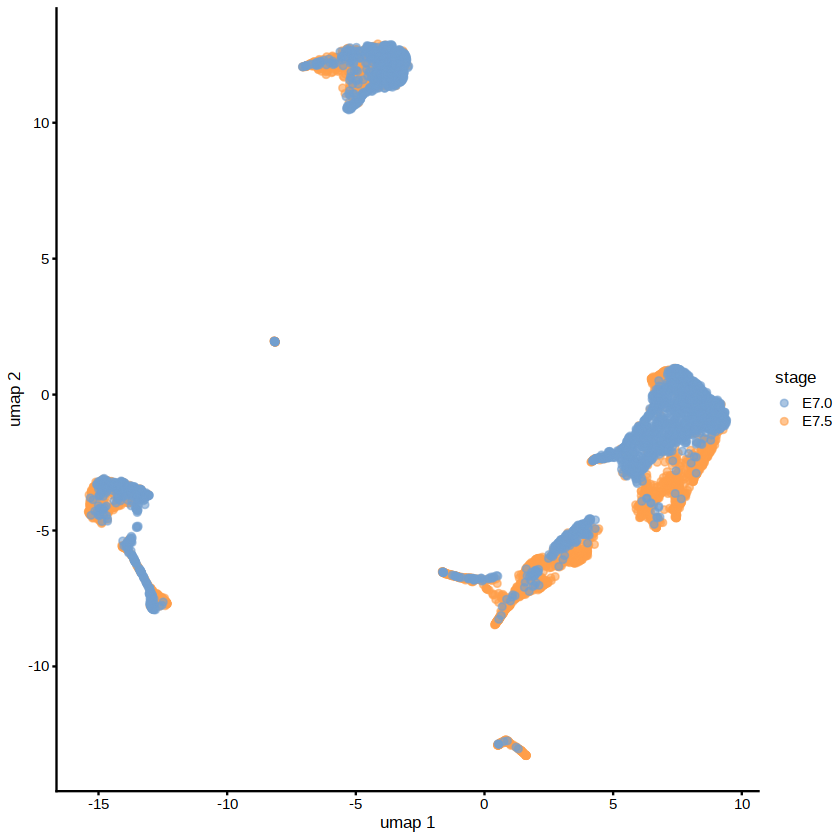

In [3]:
embryo_data <- embryo_data[,apply(reducedDim(embryo_data, "pca.corrected"), 1, function(x) !all(is.na(x)))]
embryo_data <- runUMAP(embryo_data, dimred = "pca.corrected", name = 'umap')

plotReducedDim(embryo_data, colour_by="stage", dimred = "umap") 

In [4]:
embryo_milo <- Milo(embryo_data)
embryo_milo

class: Milo 
dim: 29452 6875 
metadata(0):
assays(1): counts
rownames(29452): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000096730 ENSMUSG00000095742
rowData names(2): ENSEMBL SYMBOL
colnames(6875): cell_361 cell_362 ... cell_29013 cell_29014
colData names(17): cell barcode ... colour sizeFactor
reducedDimNames(2): pca.corrected umap
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [41]:
head(reducedDim(embryo_data, "pca.corrected"))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
cell_361,-30.7303324,3.3190994,4.180955446,-5.9722697,3.645207,-1.761977,0.5201955,-0.5874833,0.9139089,-2.117397,⋯,-2.0104026,-0.21469932,0.5933168,-1.9280495,2.52104838,0.1309430,1.5694378,-0.8442888,2.8145619,3.0227462
cell_362,4.5969289,0.4801343,0.165935203,-4.6850985,5.844813,-1.423802,5.3611417,-1.7753274,-0.5550507,-3.016635,⋯,-2.5913370,-0.54889321,-0.6974669,0.4031544,-0.13126436,0.3908976,1.2769125,-0.8034960,2.4595106,1.2614639
cell_363,0.4135806,-9.6146485,11.993130023,-0.2391353,1.400006,-1.641171,-1.4790559,-5.2599635,1.4727410,-3.707139,⋯,-1.2421909,-0.66530236,0.9629650,-1.5180939,3.84455777,1.0430128,0.5300219,1.4203920,0.8739792,-0.4494638
cell_364,-9.0719675,-12.2728031,-0.275237556,13.5048400,8.874361,-1.114243,-0.0418307,0.2122740,-1.4000226,-4.457118,⋯,-1.9807908,0.07391301,1.4757471,2.0891542,2.41145426,-2.4644595,1.3360044,2.4093880,0.9811493,1.9352164
cell_365,4.2708721,1.0560146,0.003637965,-5.3634020,8.414026,-4.289731,5.2997974,-1.3210337,-2.7506247,-4.957260,⋯,-1.2127557,-0.49363931,0.4170469,0.3825629,-0.31836884,-1.0019930,1.2275507,0.4454584,0.9024776,0.3818577
cell_366,-10.5962470,-9.6368538,-1.711665204,16.1004332,9.312752,-1.622831,2.5402251,0.5590571,-3.2641355,-1.591418,⋯,-0.2367345,-0.79261229,-0.1694283,0.4000850,-0.03905455,1.2587076,2.1390370,-1.6723184,2.3981048,0.8786638


In [5]:
embryo_milo <- buildGraph(embryo_milo, k = 30, d = 30, reduced.dim = "pca.corrected")

Constructing kNN graph with k:30



In [6]:
embryo_milo <- makeNhoods(embryo_milo, prop = 0.1, k = 30, d=30, refined = TRUE, reduced_dims = "pca.corrected")

Checking valid object



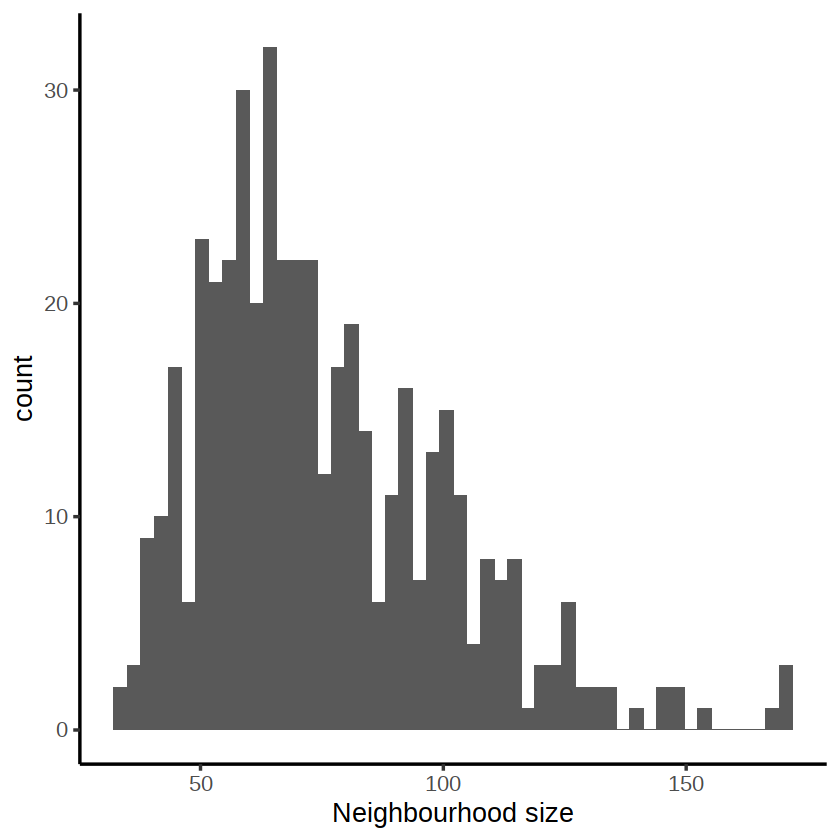

In [7]:
plotNhoodSizeHist(embryo_milo)

In [8]:
embryo_milo <- countCells(embryo_milo, meta.data = as.data.frame(colData(embryo_milo)), sample="sample")

Checking meta.data validity

Counting cells in neighbourhoods



In [9]:
head(nhoodCounts(embryo_milo))

6 x 6 sparse Matrix of class "dgCMatrix"
  2  3  6 4 10 14
1 5  7 64 6  4  2
2 3  1 44 3 10  2
3 .  2  4 1 55 24
4 .  .  5 . 83 14
5 4 10 37 6  4  5
6 4  3 88 5 58 13

In [10]:
embryo_design <- data.frame(colData(embryo_milo))[,c("sample", "stage", "sequencing.batch")]

## Convert batch info from integer to factor
embryo_design$sequencing.batch <- as.factor(embryo_design$sequencing.batch) 
embryo_design <- distinct(embryo_design)
rownames(embryo_design) <- embryo_design$sample

embryo_design

,sample,stage,sequencing.batch
,<int>,<chr>,<fct>
2,2,E7.5,1
3,3,E7.5,1
6,6,E7.5,1
4,4,E7.5,1
10,10,E7.0,1
14,14,E7.0,2


In [11]:
embryo_milo <- calcNhoodDistance(embryo_milo, d=30, reduced.dim = "pca.corrected")

In [12]:
da_results <- testNhoods(embryo_milo, design = ~ sequencing.batch + stage, design.df = embryo_design, reduced.dim="pca.corrected")
head(da_results)

Using TMM normalisation

Performing spatial FDR correction withk-distance weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2.3818445,11.45215,4.60566154,3.204127e-02,4.764579e-02,1,4.898467e-02
2,0.2015533,10.94925,0.03796758,8.455371e-01,8.663445e-01,2,8.671780e-01
3,-4.5016327,11.88769,19.85316159,9.041502e-06,3.834267e-05,3,3.415460e-05
4,-5.9194372,11.90241,33.01688377,1.123683e-08,2.573235e-07,4,2.134813e-07
5,2.2014830,11.41027,3.75325250,5.290959e-02,7.433311e-02,5,7.619519e-02
6,-1.4992818,12.27363,2.55217905,1.103722e-01,1.452599e-01,6,1.477258e-01


In [13]:
da_results %>%
  arrange(SpatialFDR) %>%
  head() 

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
363,-8.661180,11.42687,47.42456,8.672529e-12,3.972018e-09,363,3.210914e-09
108,-8.935185,11.81060,44.16243,4.345353e-11,9.950858e-09,108,7.963350e-09
63,-8.751162,11.77442,42.22540,1.134652e-10,1.732235e-08,63,1.407882e-08
154,-7.037526,11.48791,41.51214,1.616583e-10,1.850987e-08,154,1.535784e-08
109,-7.143344,11.89859,40.45485,2.733576e-10,2.503955e-08,109,2.052022e-08
360,-7.810786,12.23680,39.08763,5.397430e-10,4.120038e-08,360,3.367724e-08


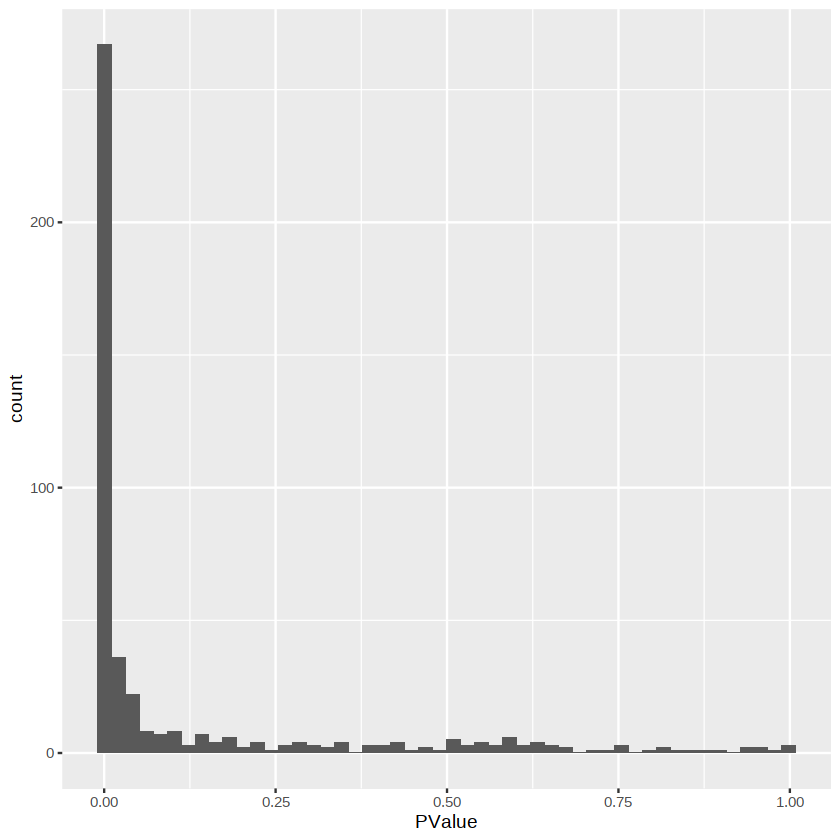

In [14]:
ggplot(da_results, aes(PValue)) + geom_histogram(bins=50)

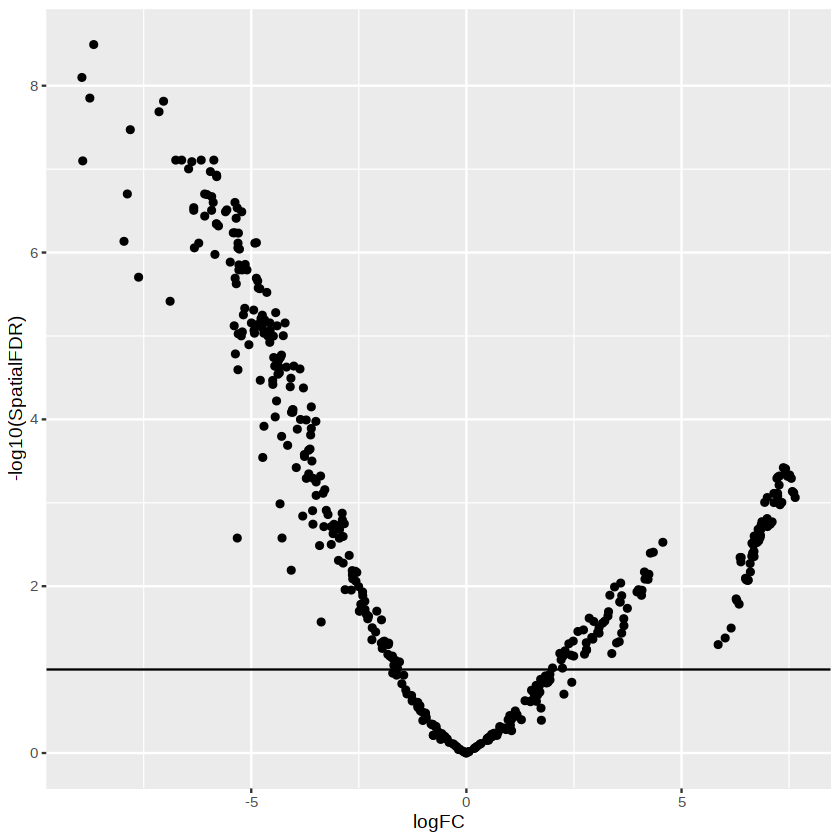

In [15]:
ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
  geom_point() +
  geom_hline(yintercept = 1) ## Mark significance threshold (10% FDR)

Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


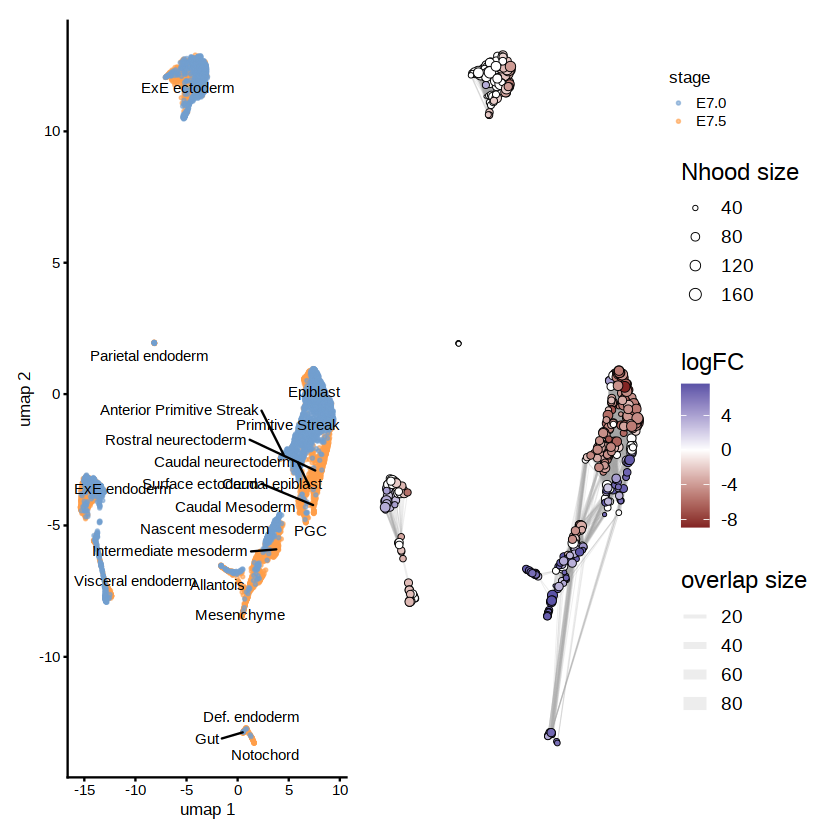

In [16]:
embryo_milo <- buildNhoodGraph(embryo_milo)

## Plot single-cell UMAP
umap_pl <- plotReducedDim(embryo_milo, dimred = "umap", colour_by="stage", text_by = "celltype", 
                          text_size = 3, point_size=0.5) +
  guides(fill="none")

## Plot neighbourhood graph
nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap",alpha=0.1) 
  
umap_pl + nh_graph_pl +
  plot_layout(guides="collect")

In [17]:
da_results <- annotateNhoods(embryo_milo, da_results, coldata_col = "celltype")
head(da_results)

Converting celltype to factor...



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype,celltype_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,2.3818445,11.45215,4.60566154,3.204127e-02,4.764579e-02,1,4.898467e-02,ExE ectoderm,1.0000000
2,0.2015533,10.94925,0.03796758,8.455371e-01,8.663445e-01,2,8.671780e-01,Epiblast,0.7777778
3,-4.5016327,11.88769,19.85316159,9.041502e-06,3.834267e-05,3,3.415460e-05,Epiblast,0.6279070
4,-5.9194372,11.90241,33.01688377,1.123683e-08,2.573235e-07,4,2.134813e-07,Epiblast,1.0000000
5,2.2014830,11.41027,3.75325250,5.290959e-02,7.433311e-02,5,7.619519e-02,ExE endoderm,1.0000000
6,-1.4992818,12.27363,2.55217905,1.103722e-01,1.452599e-01,6,1.477258e-01,ExE ectoderm,1.0000000


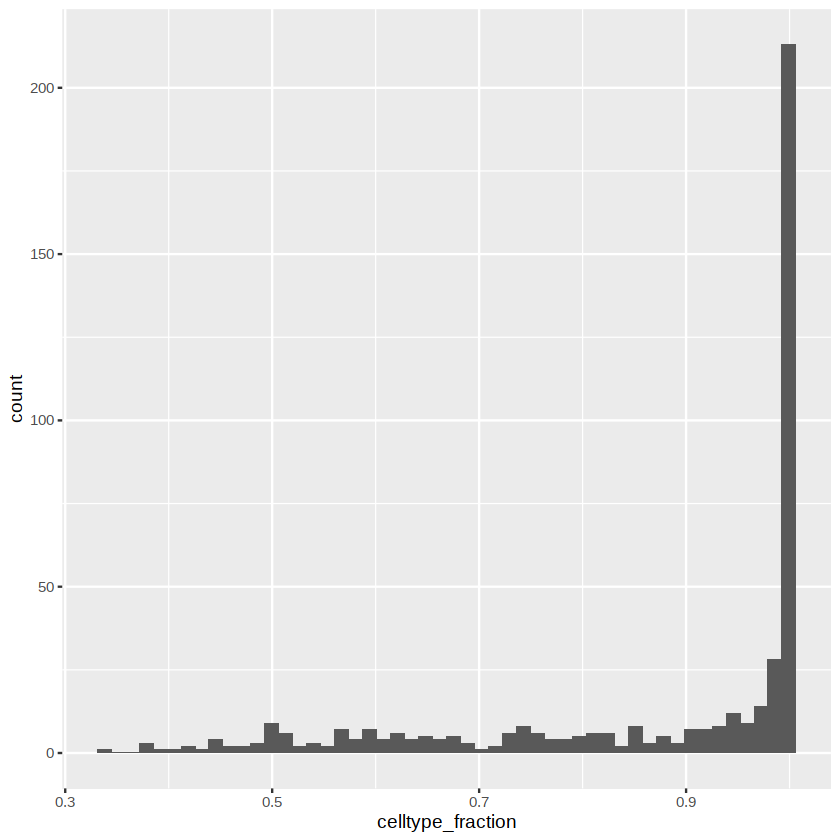

In [18]:
ggplot(da_results, aes(celltype_fraction)) + geom_histogram(bins=50)

In [19]:
da_results$celltype <- ifelse(da_results$celltype_fraction < 0.7, "Mixed", da_results$celltype)


Converting group.by to factor...



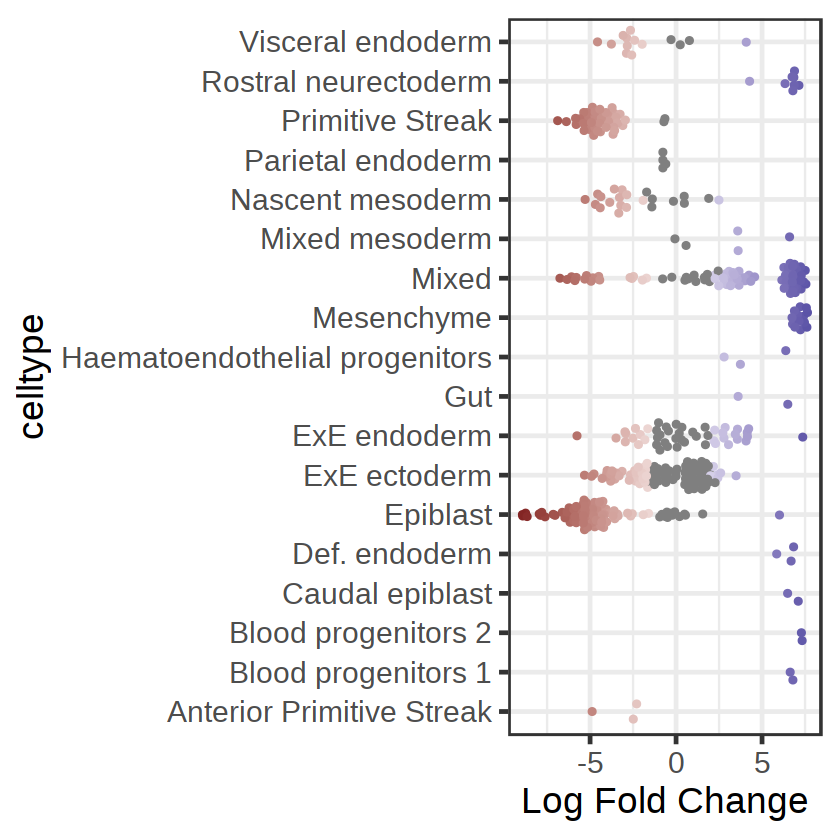

In [20]:
plotDAbeeswarm(da_results, group.by = "celltype")


In [21]:
## Add log normalized count to Milo object
embryo_milo <- logNormCounts(embryo_milo)

da_results$NhoodGroup <- as.numeric(da_results$SpatialFDR < 0.1 & da_results$logFC < 0)
da_nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = rownames(embryo_milo)[1:10])

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [22]:
head(da_nhood_markers)

,logFC_0,adj.P.Val_0,logFC_1,adj.P.Val_1,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000025902,0.0852569296,0.003539327,-0.0852569296,0.003539327,ENSMUSG00000025902
ENSMUSG00000033845,-0.0675290142,0.014585661,0.0675290142,0.014585661,ENSMUSG00000033845
ENSMUSG00000025903,-0.0525990165,0.030271461,0.0525990165,0.030271461,ENSMUSG00000025903
ENSMUSG00000104217,0.0013355485,0.258161240,-0.0013355485,0.258161240,ENSMUSG00000104217
ENSMUSG00000033813,-0.0315940518,0.258161240,0.0315940518,0.258161240,ENSMUSG00000033813
ENSMUSG00000102343,0.0002023845,1.000000000,-0.0002023845,1.000000000,ENSMUSG00000102343


In [23]:
da_nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = rownames(embryo_milo)[1:10], 
                                          aggregate.samples = TRUE, sample_col = "sample")

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [24]:
head(da_nhood_markers)

,logFC_0,adj.P.Val_0,logFC_1,adj.P.Val_1,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000033845,-0.194246812,1,0.194246812,1,ENSMUSG00000033845
ENSMUSG00000025900,0.001960588,1,-0.001960588,1,ENSMUSG00000025900
ENSMUSG00000033813,-0.063629206,1,0.063629206,1,ENSMUSG00000033813
ENSMUSG00000025902,-0.158892356,1,0.158892356,1,ENSMUSG00000025902
ENSMUSG00000104217,0.000350278,1,-0.000350278,1,ENSMUSG00000104217
ENSMUSG00000025903,0.050675338,1,-0.050675338,1,ENSMUSG00000025903


In [25]:
## Run buildNhoodGraph to store nhood adjacency matrix
embryo_milo <- buildNhoodGraph(embryo_milo)

## Find groups
da_results <- groupNhoods(embryo_milo, da_results, max.lfc.delta = 10)
head(da_results)

Found 333 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype,celltype_fraction,NhoodGroup
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,2.3818445,11.45215,4.60566154,3.204127e-02,4.764579e-02,1,4.898467e-02,ExE ectoderm,1.0000000,1
2,0.2015533,10.94925,0.03796758,8.455371e-01,8.663445e-01,2,8.671780e-01,Epiblast,0.7777778,2
3,-4.5016327,11.88769,19.85316159,9.041502e-06,3.834267e-05,3,3.415460e-05,Mixed,0.6279070,3
4,-5.9194372,11.90241,33.01688377,1.123683e-08,2.573235e-07,4,2.134813e-07,Epiblast,1.0000000,2
5,2.2014830,11.41027,3.75325250,5.290959e-02,7.433311e-02,5,7.619519e-02,ExE endoderm,1.0000000,4
6,-1.4992818,12.27363,2.55217905,1.103722e-01,1.452599e-01,6,1.477258e-01,ExE ectoderm,1.0000000,1


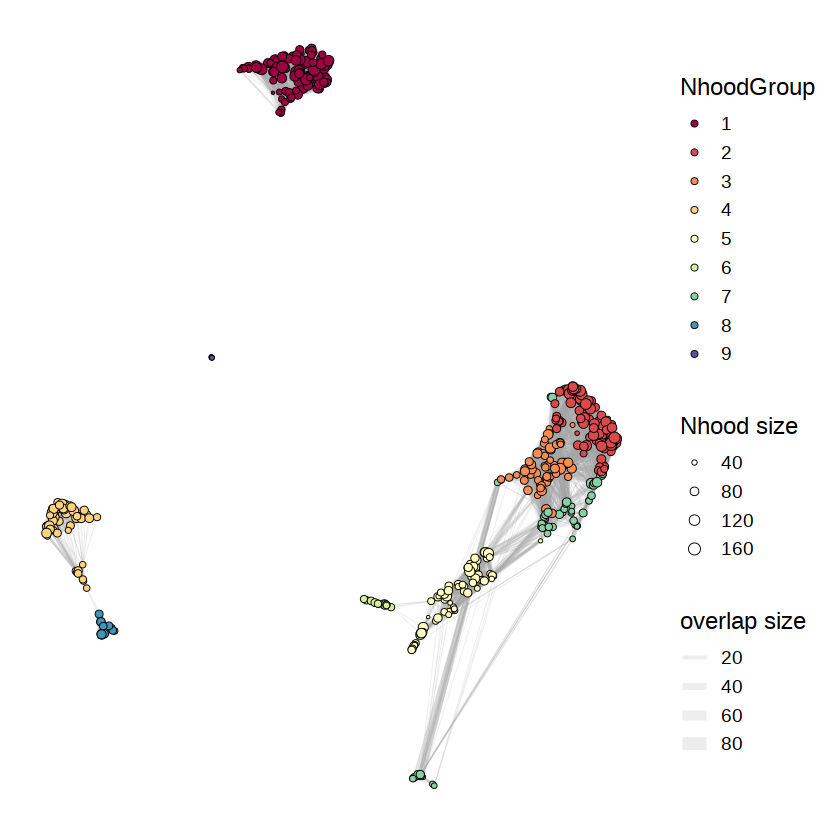

In [26]:
plotNhoodGroups(embryo_milo, da_results, layout="umap") 

Converting group.by to factor...



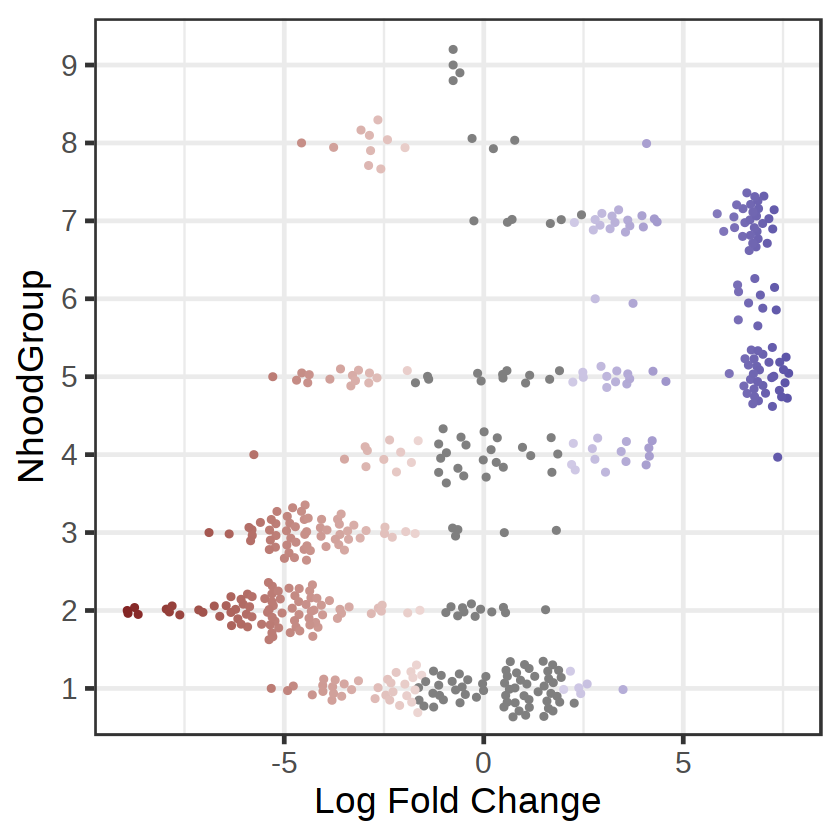

In [27]:
plotDAbeeswarm(da_results, "NhoodGroup")

Found 333 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping



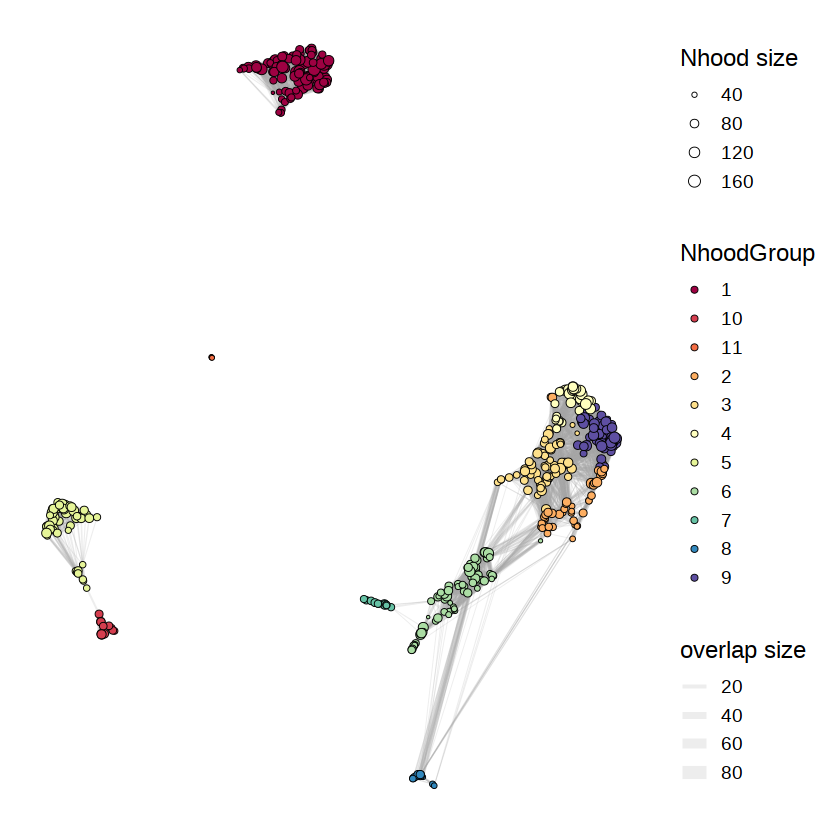

In [28]:
set.seed(42)
da_results <- groupNhoods(embryo_milo, da_results, max.lfc.delta = 5, overlap=5)
plotNhoodGroups(embryo_milo, da_results, layout="umap")

Converting group.by to factor...



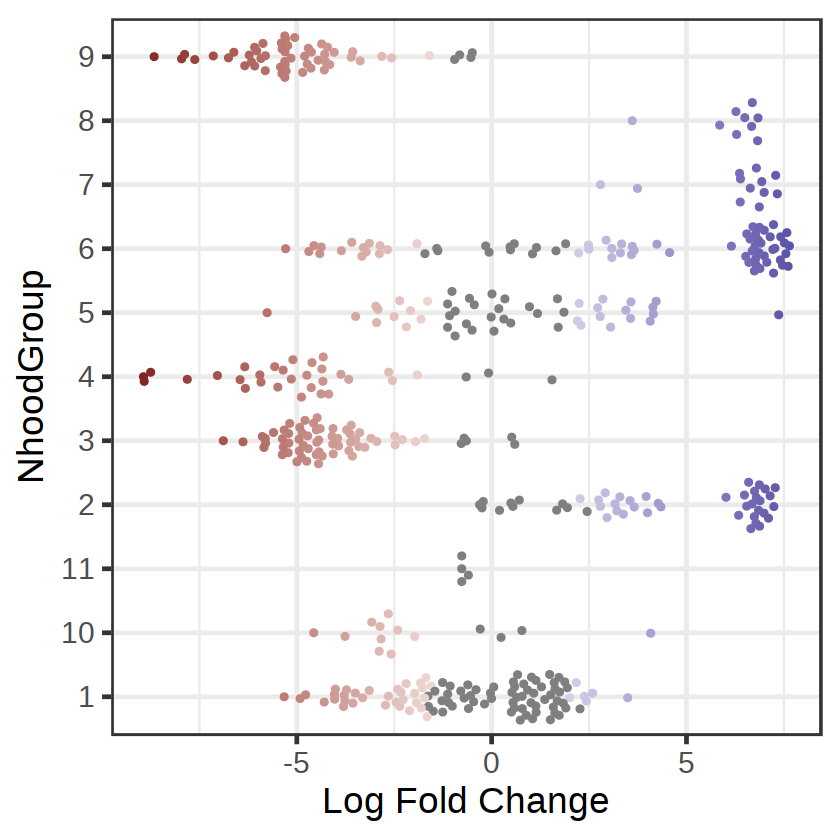

In [29]:
plotDAbeeswarm(da_results, group.by = "NhoodGroup")

In [30]:
## Exclude zero counts genes
keep.rows <- rowSums(logcounts(embryo_milo)) != 0
embryo_milo <- embryo_milo[keep.rows, ]

## Find HVGs
set.seed(101)
dec <- modelGeneVar(embryo_milo)
hvgs <- getTopHVGs(dec, n=2000)
head(hvgs)

[1] "ENSMUSG00000032083" "ENSMUSG00000095180" "ENSMUSG00000061808"
[4] "ENSMUSG00000002985" "ENSMUSG00000024990" "ENSMUSG00000024391"

In [31]:
set.seed(42)
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs, 
                                       aggregate.samples = TRUE, sample_col = "sample")

head(nhood_markers)

,logFC_1,adj.P.Val_1,logFC_2,adj.P.Val_2,logFC_3,adj.P.Val_3,logFC_4,adj.P.Val_4,logFC_5,adj.P.Val_5,⋯,adj.P.Val_7,logFC_8,adj.P.Val_8,logFC_9,adj.P.Val_9,logFC_10,adj.P.Val_10,logFC_11,adj.P.Val_11,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000027186,2.6285439,1.172600e-54,0.4573121,2.334379e-07,0.7954342,2.827504e-05,0.4782332,7.783916e-08,1.502465,1.460413e-46,⋯,1.308991e-38,0.5750015,5.365270e-14,1.8908255,0.002063781,1.1190147,3.669296e-38,3.278838,2.897031e-58,ENSMUSG00000027186
ENSMUSG00000042367,2.4494887,2.557294e-38,0.6287964,2.334379e-07,0.7349817,1.354185e-03,0.5164532,9.072353e-07,2.752881,8.507875e-45,⋯,1.483085e-37,0.7229855,1.587599e-13,1.0396398,0.003653871,1.4433328,6.375865e-22,3.940708,2.610667e-54,ENSMUSG00000042367
ENSMUSG00000073243,0.9433798,2.557294e-38,0.3824694,3.168210e-06,0.5762818,2.130219e-03,0.5336451,1.209104e-05,2.687943,1.425561e-42,⋯,3.305334e-30,1.1686016,4.097025e-13,0.3222594,0.008519428,0.8038941,1.114076e-18,3.709108,2.906466e-51,ENSMUSG00000073243
ENSMUSG00000027225,0.7469867,2.096012e-35,0.5209745,4.890324e-06,0.4715935,1.866465e-02,1.9453231,1.415936e-05,2.315829,2.501801e-39,⋯,2.339772e-29,0.6710902,2.377115e-12,0.7408876,0.012401260,0.8136437,1.966274e-18,3.181547,1.073758e-39,ENSMUSG00000027225
ENSMUSG00000006205,1.8489208,3.176184e-35,0.6156185,2.491058e-05,0.7125107,2.673176e-02,0.6806909,3.386181e-05,1.738097,3.332575e-37,⋯,7.077834e-25,0.6776552,6.725889e-12,0.2391082,0.018573877,0.9647633,1.932622e-16,4.317741,7.752577e-38,ENSMUSG00000006205
ENSMUSG00000001025,1.8751143,1.033233e-34,0.3502682,4.169857e-05,0.5731713,3.119687e-02,0.3036732,4.159045e-05,1.722407,2.695075e-35,⋯,5.143597e-20,0.6212448,6.174514e-11,0.5538477,0.018573877,0.8561389,6.965136e-15,3.246855,5.913993e-37,ENSMUSG00000001025


In [32]:
gr5_markers <- nhood_markers[c("logFC_5", "adj.P.Val_5")] 
colnames(gr5_markers) <- c("logFC", "adj.P.Val")

head(gr5_markers[order(gr5_markers$adj.P.Val), ])

,logFC,adj.P.Val
,<dbl>,<dbl>
ENSMUSG00000027186,1.502465,1.460413e-46
ENSMUSG00000042367,2.752881,8.507875e-45
ENSMUSG00000073243,2.687943,1.425561e-42
ENSMUSG00000027225,2.315829,2.501801e-39
ENSMUSG00000006205,1.738097,3.332575e-37
ENSMUSG00000001025,1.722407,2.695075e-35


In [33]:
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs, 
                                       aggregate.samples = TRUE, sample_col = "sample",
                                       subset.groups = c("5")
                                       )

Warning message in all(structure(c(1.50246477502317, 2.7528806059783, 2.6879425348665, :
“coercing argument of type 'double' to logical”


In [34]:
head(nhood_markers)

,logFC_5,adj.P.Val_5,GeneID
,<dbl>,<dbl>,<chr>
ENSMUSG00000059412,1.502465,1.460413e-46,ENSMUSG00000059412
ENSMUSG00000043501,2.752881,8.507875e-45,ENSMUSG00000043501
ENSMUSG00000031883,2.687943,1.425561e-42,ENSMUSG00000031883
ENSMUSG00000028307,2.315829,2.501801e-39,ENSMUSG00000028307
ENSMUSG00000028435,1.738097,3.332575e-37,ENSMUSG00000028435
ENSMUSG00000027690,1.722407,2.695075e-35,ENSMUSG00000027690


In [35]:
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs,
                                       subset.nhoods = da_results$NhoodGroup %in% c('5','6'),
                                       aggregate.samples = TRUE, sample_col = "sample")

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [36]:
head(nhood_markers)

,logFC_5,adj.P.Val_5,logFC_6,adj.P.Val_6,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000024391,5.861832,6.196019e-13,-5.861832,6.196019e-13,ENSMUSG00000024391
ENSMUSG00000032083,7.004622,6.196019e-13,-7.004622,6.196019e-13,ENSMUSG00000032083
ENSMUSG00000061808,6.916851,1.064876e-12,-6.916851,1.064876e-12,ENSMUSG00000061808
ENSMUSG00000031765,4.603518,1.535327e-12,-4.603518,1.535327e-12,ENSMUSG00000031765
ENSMUSG00000032359,4.372320,1.644610e-12,-4.372320,1.644610e-12,ENSMUSG00000032359
ENSMUSG00000021278,4.543839,2.513612e-12,-4.543839,2.513612e-12,ENSMUSG00000021278


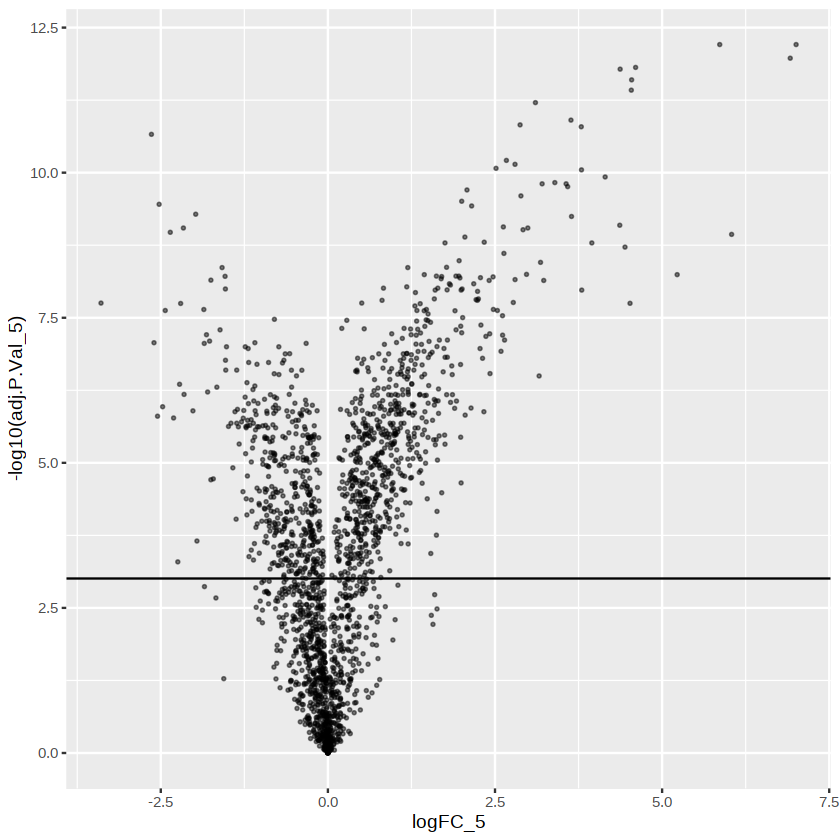

In [37]:
ggplot(nhood_markers, aes(logFC_5, -log10(adj.P.Val_5 ))) + 
  geom_point(alpha=0.5, size=0.5) +
  geom_hline(yintercept = 3)

In [38]:
markers <- rownames(nhood_markers)[nhood_markers$adj.P.Val_5 < 0.01 & nhood_markers$logFC_5 > 0]


Warning message in plotNhoodExpressionGroups(embryo_milo, da_results, features = intersect(rownames(embryo_milo), :
“Nothing in nhoodExpression(x): computing for requested features...”


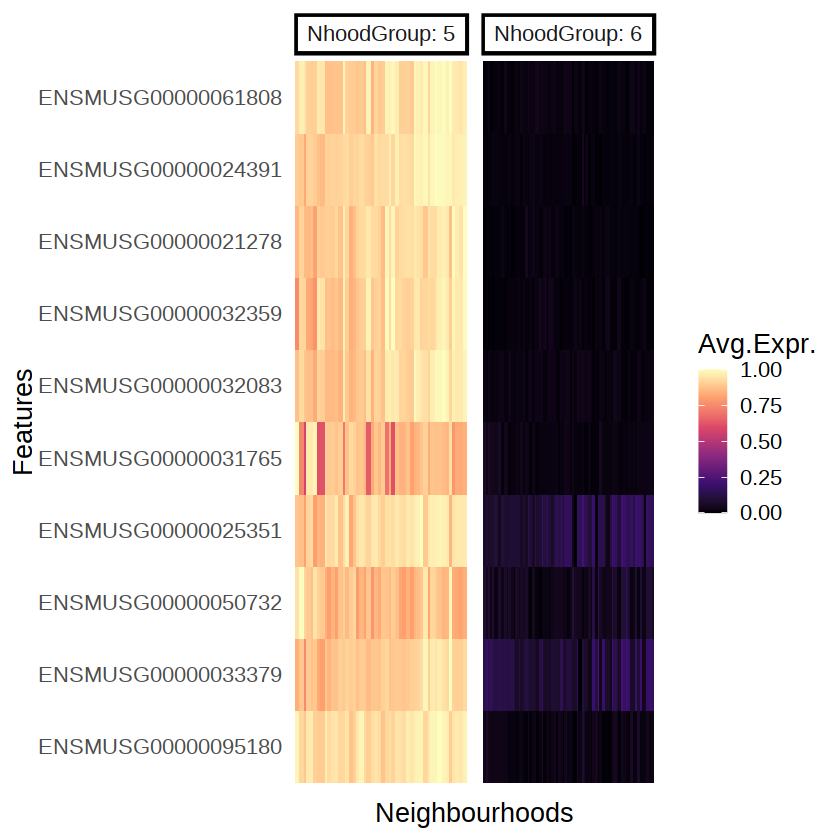

In [39]:
set.seed(42)
plotNhoodExpressionGroups(embryo_milo, da_results, features=intersect(rownames(embryo_milo), markers[1:10]),
                          subset.nhoods = da_results$NhoodGroup %in% c('6','5'), 
                          scale=TRUE,
                          grid.space = "fixed")

In [40]:
dge_6 <- testDiffExp(embryo_milo, da_results, design = ~ stage, meta.data = data.frame(colData(embryo_milo)),
                     subset.row = rownames(embryo_milo)[1:5], subset.nhoods=da_results$NhoodGroup=="6")

dge_6

Warning message in fitFDist(var, df1 = df, covariate = covariate):
“More than half of residual variances are exactly zero: eBayes unreliable”


,logFC,AveExpr,t,P.Value,adj.P.Val,B,Nhood.Group
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000025902,-0.02441640,0.02719437,-2.066917,0.03898193,0.1949097,-8.977265,6
ENSMUSG00000033845,-0.02963583,2.28381975,-0.682995,0.49475779,1.0000000,-10.877667,6
ENSMUSG00000051951,0.00000000,0.00000000,0.000000,1.00000000,1.0000000,-11.111075,6
ENSMUSG00000102343,0.00000000,0.00000000,0.000000,1.00000000,1.0000000,-11.111075,6
ENSMUSG00000025900,0.00000000,0.00000000,0.000000,1.00000000,1.0000000,-11.111075,6
